# Footnote Tool

In [1]:
from pprint import pprint
import re
from collections import Counter

with open('../writeup/writeup.md', 'r') as infile:
    data = infile.read()

fn = list(map(int, sorted(re.findall(r'\[\^(\d+)\]', data))))
fn = Counter(fn)
# pprint(fn)


print(f'----------------\nTotal Footnotes: {sum([v for v in fn.values()])//2}')
problems = []
for k, v in fn.items():
    if v != 2:
        problems.append(k)
if problems:
    print(f'Problems:')
    for problem in problems:
        print(problem)
else:
    print(f'No Footnote Problems!')
print('-----------------\n')

----------------
Total Footnotes: 28
No Footnote Problems!
-----------------



# Export

In [2]:
!ls ../writeup

anon.md     anon.pdf    header.tex  indent.tex  writeup.md  writeup.pdf


In [3]:
!pandoc ../writeup/writeup.md -o ../writeup/writeup.pdf --pdf-engine=xelatex -V geometry:margin=1in -V indent=true --toc --toc-depth=3 --number-sections 
# !pandoc README.md -o draft.pdf --pdf-engine=xelatex -V geometry:margin=1in -V indent=true --number-sections 

In [15]:
#anon
import re 
import os
from pprint import pprint

with open('../writeup/writeup.md', 'r') as infile:
    data = infile.read()

PII = ['Justin Tung', 
       'Transactional Practice Innovation Lead at Jackson Walker LLP. The author holds a J.D. from the University of Texas School of law, MSLIS from the University of Illinois, and a BA from Boston College. ',
       'Reference Librarian and Lecturer at the University of Texas School of Law', 
       'Reference Librarian and Lecturer at the Univ. Tex.,', 
       'https://github.com/JayTongue/Sherlock_HoLLMes']
# PII = [re.escape(i) for i in PII]
pprint(PII)

for info in PII:
    # data = re.sub(rf'{info}', '[AUTHOR INFO]', data)
    data = data.replace(info, '[AUTHOR INFO]')

outfile_name = '../writeup/anon'
with open(f'{outfile_name}.md', 'w') as outfile:
    print(data, file=outfile)

!pandoc ../writeup/anon.md -o ../writeup/anon.pdf --pdf-engine=xelatex -V geometry:margin=1in -V indent=true --toc --toc-depth=3 --number-sections

print('Done!')

['Justin Tung',
 'Transactional Practice Innovation Lead at Jackson Walker LLP. The author '
 'holds a J.D. from the University of Texas School of law, MSLIS from the '
 'University of Illinois, and a BA from Boston College. ',
 'Reference Librarian and Lecturer at the University of Texas School of Law',
 'Reference Librarian and Lecturer at the Univ. Tex.,',
 'https://github.com/JayTongue/Sherlock_HoLLMes']
Done!


In [ ]:
#export to 
!pandoc ../writeup/writeup.md \
  --standalone \
  --to=latex \
  --output=../writeup/writeup.tex \
  --toc \
  --toc-depth=3 \
  --number-sections \
  -V geometry:margin=1in \
  --include-in-header=../writeup/header.tex \
  --include-in-header=../writeup/indent.tex

  

-----------
# Analyze

In [43]:
import json
from collections import defaultdict
from pprint import pprint
import copy
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle
import numpy as np
from scipy.optimize import curve_fit
import os

In [2]:
with open('results.json', 'r') as infile:
    data = json.load(infile)
data

{'size': {'10': {'trial': {'0': {'platform': {'Lexis': {'contracts': 3,
       'enron': 6,
       'markov': 4,
       'random': None,
       'zeros': None},
      'Westlaw': {'contracts': 6,
       'enron': 6,
       'markov': 5,
       'random': 6,
       'zeros': 6},
      'Harvey': {'contracts': 6,
       'enron': 6,
       'markov': 6,
       'random': 6,
       'zeros': 6}}},
    '1': {'platform': {'Lexis': {'contracts': 4,
       'enron': 5,
       'markov': 4,
       'random': None,
       'zeros': None},
      'Westlaw': {'contracts': 3,
       'enron': 5,
       'markov': 6,
       'random': 6,
       'zeros': 6},
      'Harvey': {'contracts': 6,
       'enron': 5,
       'markov': 6,
       'random': 6,
       'zeros': 4}}},
    '2': {'platform': {'Lexis': {'contracts': 4,
       'enron': 5,
       'markov': 5,
       'random': None,
       'zeros': None},
      'Westlaw': {'contracts': 4,
       'enron': 4,
       'markov': 4,
       'random': 6,
       'zeros': 5},
      'H

In [11]:
new_dict = {i: {'contracts': {10: [], 25: [], 50: [], 100: [], 250: [], 500: []}, 
                'enron': {10: [], 25: [], 50: [], 100: [], 250: [], 500: []}, 
                'markov': {10: [], 25: [], 50: [], 100: [], 250: [], 500: []}, 
                'random': {10: [], 25: [], 50: [], 100: [], 250: [], 500: []}, 
                'zeros': {10: [], 25: [], 50: [], 100: [], 250: [], 500: []}} for i in ['Lexis', 'Westlaw', 'Harvey']}

# for size in data['size']:
#     for trial in data['size'][size]['trial'].keys():
#         for vendor in ['Lexis', 'Westlaw', 'Harvey']:
#             for corp_type in ['contracts', 'enron', 'markov', 'random', 'zeros']:
#                 new_dict[vendor][corp_type][int(size)].append(data['size'][size]['trial'][trial]['platform'][vendor][corp_type])
# pprint(new_dict)

for size in data['size']:
    for trial in data['size'][size]['trial'].keys():
        for vendor in ['Lexis', 'Westlaw', 'Harvey']:
            for corp_type in ['contracts', 'enron', 'markov', 'random', 'zeros']:
                point = data['size'][size]['trial'][trial]['platform'][vendor][corp_type]
                if point:
                    # print(type(point))
                    new_dict[vendor][corp_type][int(size)].append(data['size'][size]['trial'][trial]['platform'][vendor][corp_type]*100 / 6)
                else: 
                    new_dict[vendor][corp_type][int(size)].append(None)
pprint(new_dict)

{'Harvey': {'contracts': {10: [100.0,
                               100.0,
                               100.0,
                               83.33333333333333,
                               83.33333333333333,
                               66.66666666666667,
                               100.0,
                               100.0,
                               100.0,
                               83.33333333333333],
                          25: [50.0,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0,
                               33.333333333333336,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0],
                          50: [50.0,
                               50.0,
                               50.0,
                               33.3333333333333

--------------
# Quartile breakdown

In [12]:
stats_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for vendor in new_dict:
    for corp in new_dict[vendor]:
        for size in new_dict[vendor][corp]:
            trials = new_dict[vendor][corp][size]
            trials = sorted([x for x in trials if x is not None])
            if len(trials) > 5:
                mean = sum(trials) / len(trials)
                if len(trials) % 2 == 1:
                    bottom_half, top_half = trials[:len(trials)//2], trials[len(trials)//2+1:]
                else:
                    bottom_half, top_half = trials[:len(trials)//2], trials[len(trials)//2:]
                q1, q3 = map(lambda x: sum(x)/len(x), [bottom_half, top_half])
                # print(vendor, corp, size)
                # print(q1, mean, q3)
                stats_dict[vendor][corp][size]['q1'] = q1
                stats_dict[vendor][corp][size]['mean'] = mean
                stats_dict[vendor][corp][size]['q3'] = q3

pprint(stats_dict)


defaultdict(<function <lambda> at 0x12184b420>,
            {'Harvey': defaultdict(<function <lambda>.<locals>.<lambda> at 0x121849620>,
                                   {'contracts': defaultdict(<class 'dict'>,
                                                             {10: {'mean': 91.66666666666666,
                                                                   'q1': 83.33333333333333,
                                                                   'q3': 100.0},
                                                              25: {'mean': 45.0,
                                                                   'q1': 40.0,
                                                                   'q3': 50.0},
                                                              50: {'mean': 55.0,
                                                                   'q1': 46.66666666666667,
                                                                   'q3': 63.333333333333336},
            

In [53]:
import matplotlib.pyplot as plt

def make_graph(vendor, corp):
    d = stats_dict[vendor][corp]
    xs = sorted(d.keys())

    means = [d[x]['mean'] for x in xs]
    q1s   = [d[x]['q1']   for x in xs]
    q3s   = [d[x]['q3']   for x in xs]

    plt.figure(figsize=(10, 6))

    plt.plot(xs, q1s, linestyle='--', marker='o', label='q1')
    plt.plot(xs, q3s, linestyle='--', marker='o', label='q3')

    plt.plot(xs, means, linestyle='-', marker='o', label='mean')

    plt.fill_between(xs, q1s, q3s, alpha=0.15)

    plt.xscale('log')
    plt.xticks(xs, [str(x) for x in xs])
    
    plt.xlabel('Number of Files')
    plt.ylabel('% Correct Reponses')
    plt.ylim(0, 110)
    plt.xlim(0, 600)
    plt.title(f'{vendor} - {corp}')
    plt.legend()
    plt.savefig(f'../data_visualizations/quartiles/{vendor}_{corp.title()}.png')
    plt.show()


/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


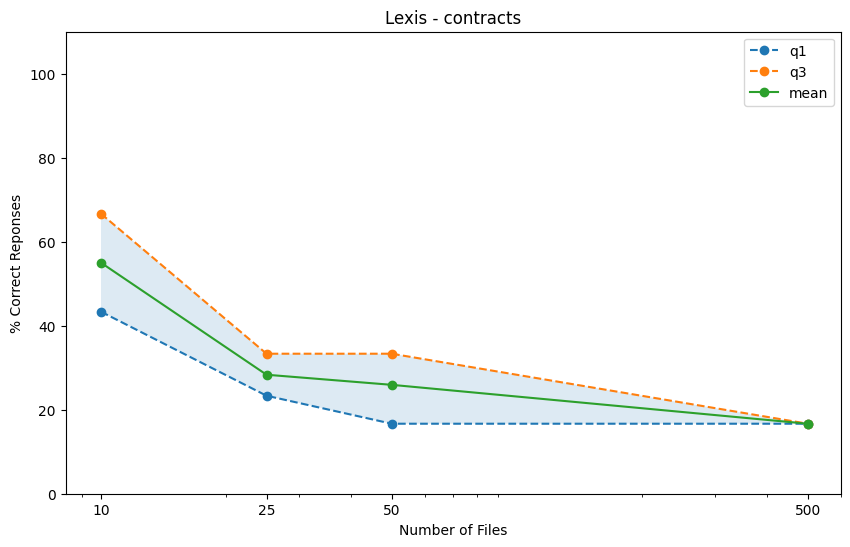

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


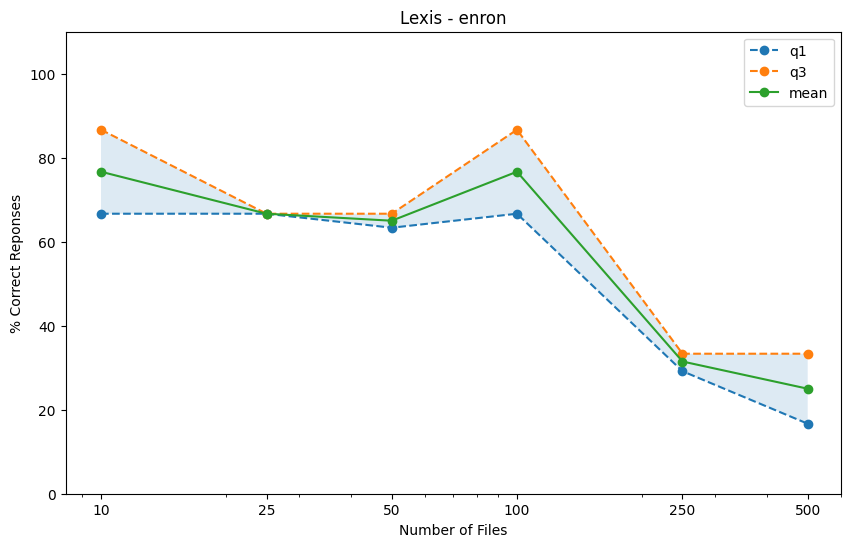

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


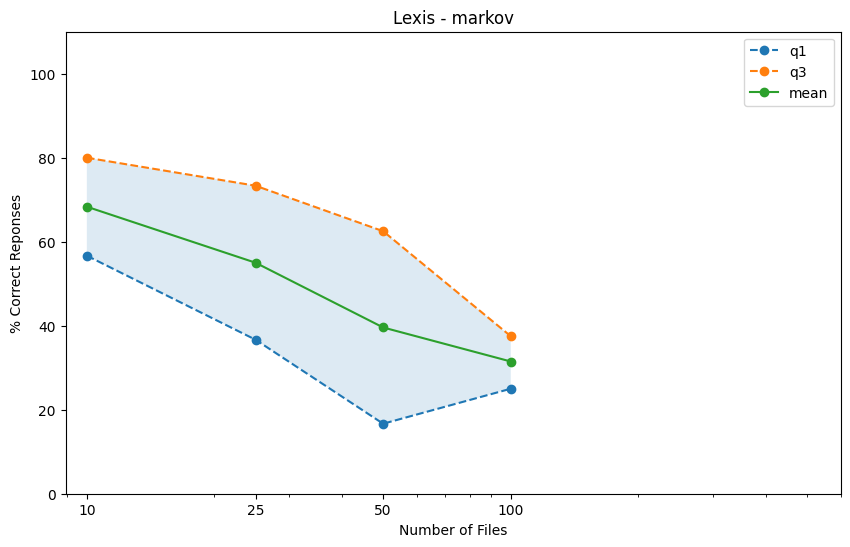

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


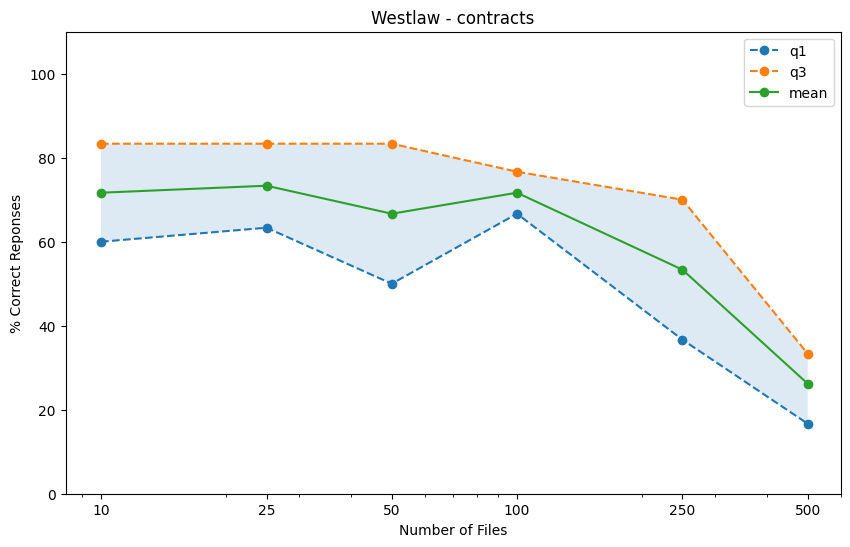

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


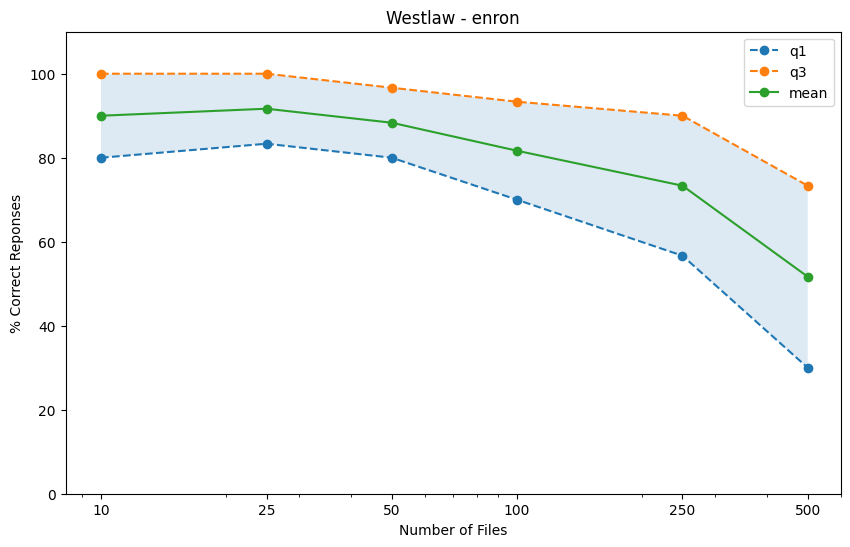

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


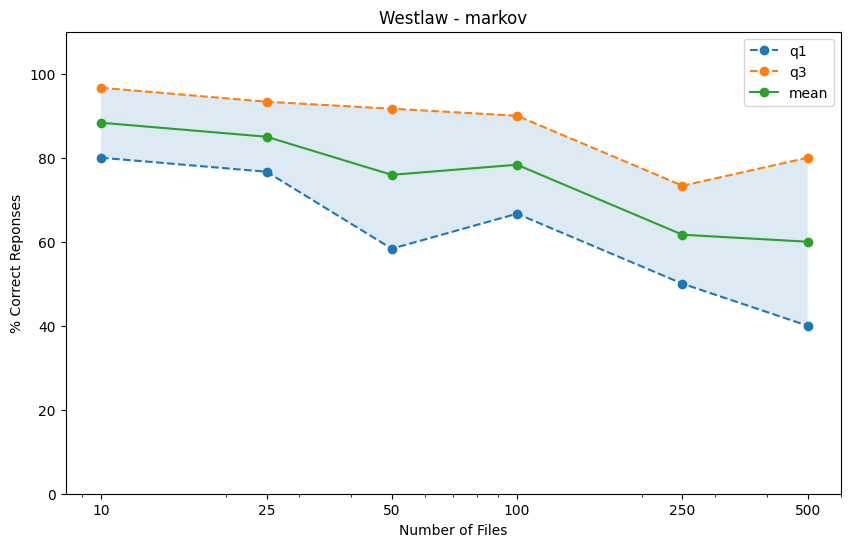

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


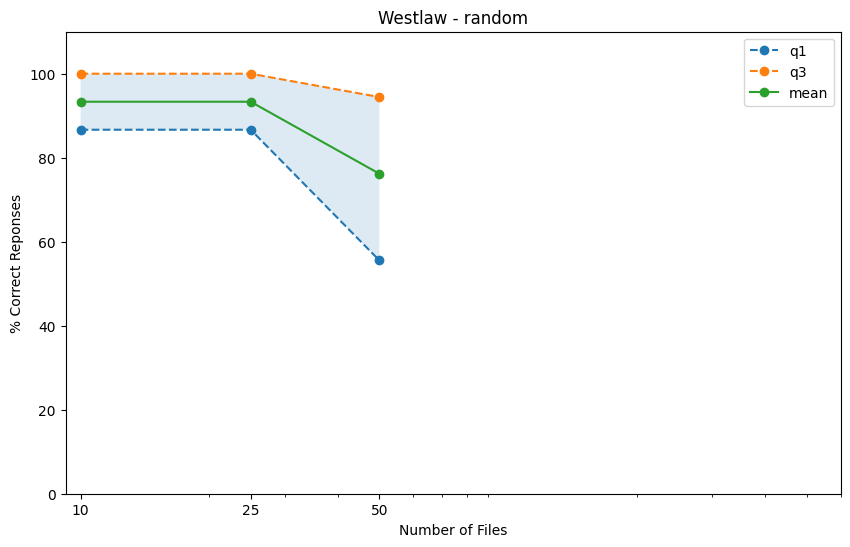

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


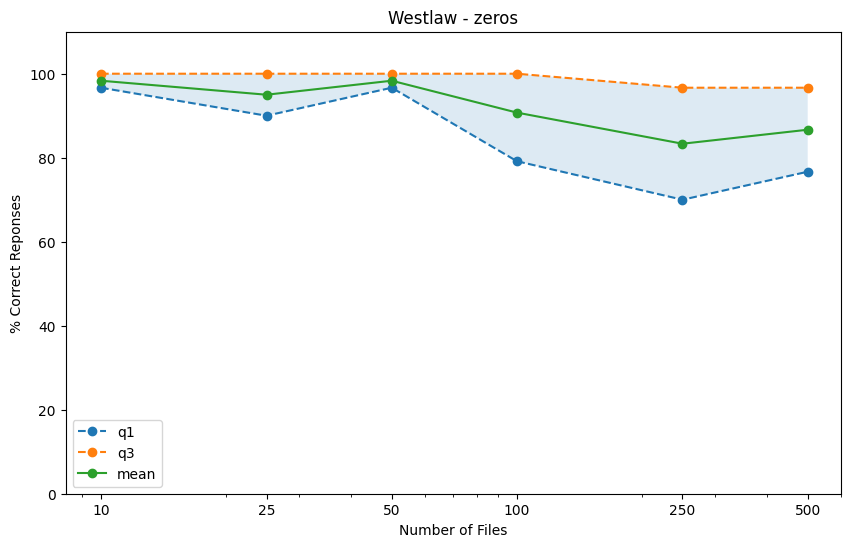

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


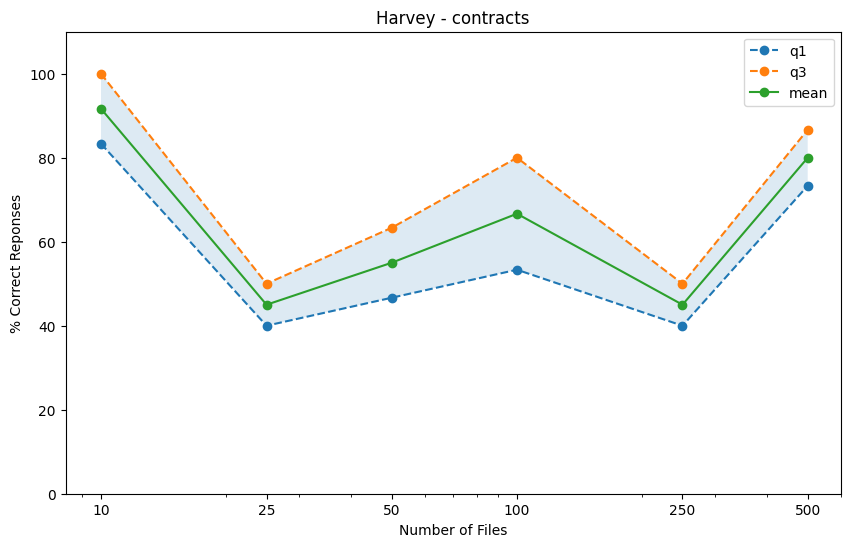

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


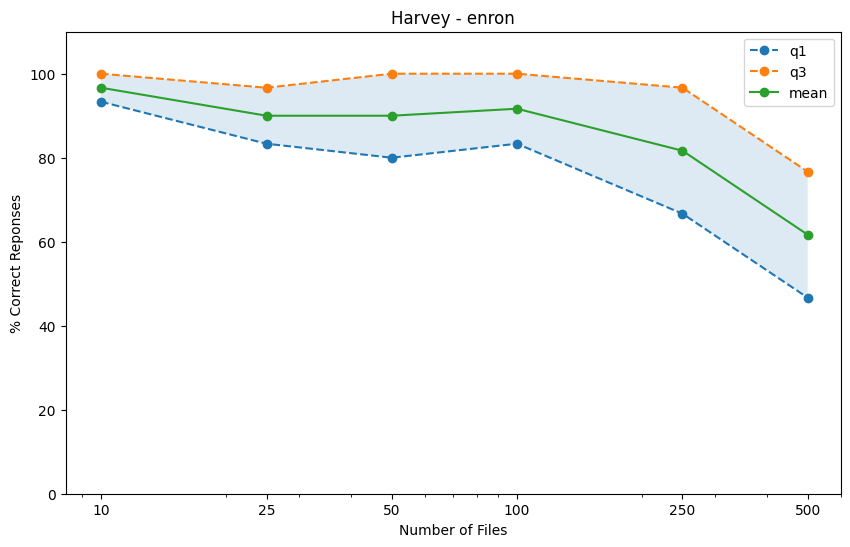

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


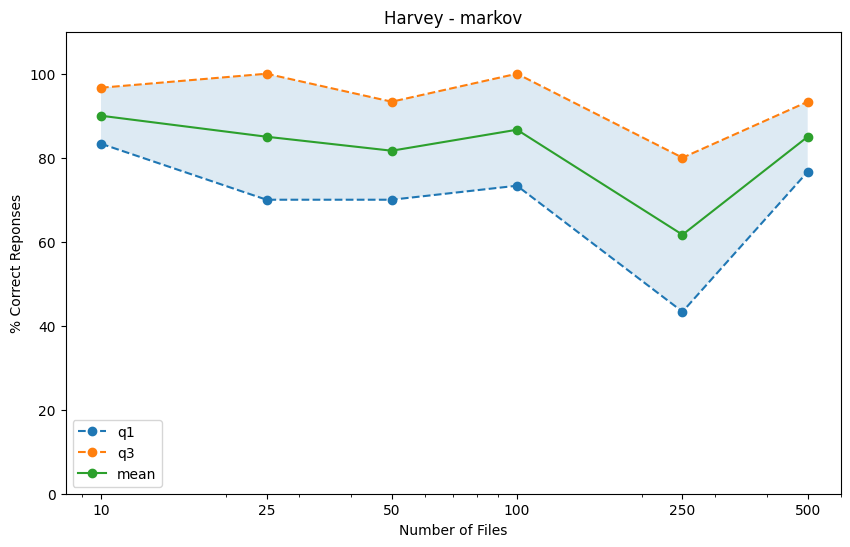

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


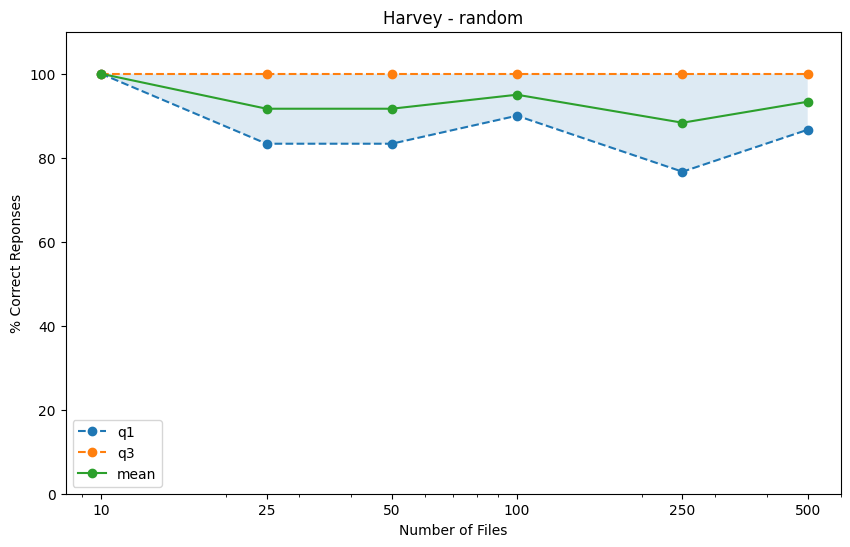

/var/folders/6_/k0_nmk_j3c766qsynb7pr0h40000gp/T/ipykernel_22232/892804098.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 600)


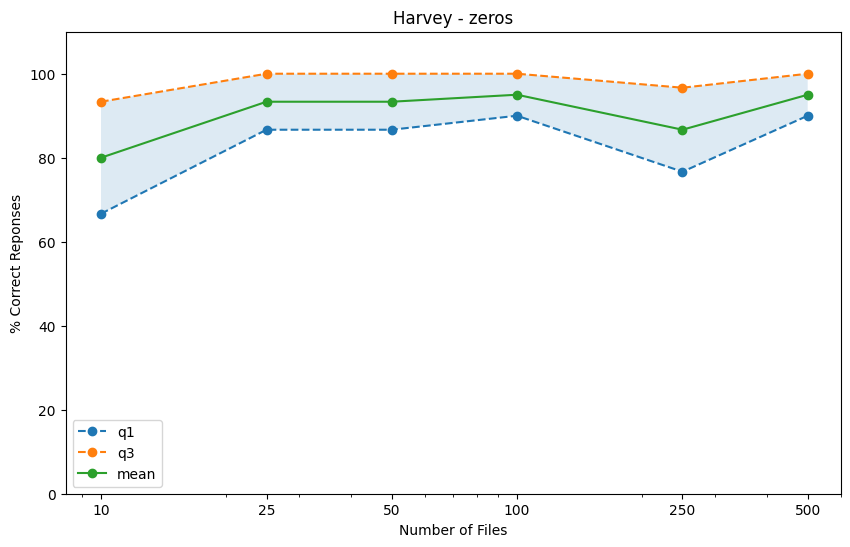

In [54]:
for vendor in stats_dict:
    for corp in stats_dict[vendor]:
        make_graph(vendor, corp)

--------------------
# Averaged Nonlinear Regression

In [19]:

paired_points = {}
for vendor in stats_dict:
    vendor_dict = {}
    for corpora in stats_dict[vendor]:
        corp_list = []
        for size in stats_dict[vendor][corpora]:
            corp_list.append((size, stats_dict[vendor][corpora][size]['mean']))
        vendor_dict[corpora] = corp_list
    paired_points[vendor] = vendor_dict

print(paired_points)
     

{'Lexis': {'contracts': [(10, 55.0), (25, 28.333333333333336), (50, 25.925925925925927), (500, 16.666666666666668)], 'enron': [(10, 76.66666666666666), (25, 66.66666666666667), (50, 65.0), (100, 76.66666666666666), (250, 31.481481481481485), (500, 25.0)], 'markov': [(10, 68.33333333333334), (25, 55.0), (50, 39.583333333333336), (100, 31.481481481481485)]}, 'Westlaw': {'contracts': [(10, 71.66666666666666), (25, 73.33333333333334), (50, 66.66666666666666), (100, 71.66666666666667), (250, 53.333333333333336), (500, 26.190476190476193)], 'enron': [(10, 90.0), (25, 91.66666666666666), (50, 88.33333333333333), (100, 81.66666666666666), (250, 73.33333333333334), (500, 51.666666666666664)], 'markov': [(10, 88.33333333333333), (25, 85.0), (50, 75.92592592592592), (100, 78.33333333333334), (250, 61.666666666666664), (500, 60.0)], 'random': [(10, 93.33333333333334), (25, 93.33333333333334), (50, 76.19047619047619)], 'zeros': [(10, 98.33333333333334), (25, 95.0), (50, 98.33333333333334), (100, 90

--------------
# breakdown by corpus

In [20]:
# pprint(paired_points)

corp_avg_dict = {}
for corp in ['contracts', 'enron', 'markov', 'random', 'zeros']:
    small_avgs = defaultdict(list)
    for vender in paired_points:
        if corp in paired_points[vender].keys():
            for size, val in paired_points[vender][corp]:
                # print(corp, vender, size, val)
                small_avgs[size].append(val)
    small_avgs = {k: sum(v)/len(v) for k, v in small_avgs.items()}
    corp_avg_dict[corp] = small_avgs
pprint(corp_avg_dict)
with open('corp_avg_dict.json', 'w') as outfile:
    json.dump(corp_avg_dict, outfile, indent=4)

{'contracts': {10: 72.77777777777777,
               25: 48.88888888888889,
               50: 49.197530864197525,
               100: 69.16666666666666,
               250: 49.16666666666667,
               500: 40.952380952380956},
 'enron': {10: 87.77777777777777,
           25: 82.77777777777777,
           50: 81.1111111111111,
           100: 83.33333333333333,
           250: 62.1604938271605,
           500: 46.111111111111114},
 'markov': {10: 82.22222222222223,
            25: 75.0,
            50: 65.7253086419753,
            100: 65.49382716049384,
            250: 61.666666666666664,
            500: 72.5},
 'random': {10: 96.66666666666667,
            25: 92.5,
            50: 83.92857142857142,
            100: 95.0,
            250: 88.33333333333334,
            500: 93.33333333333334},
 'zeros': {10: 89.16666666666667,
           25: 94.16666666666667,
           50: 95.83333333333334,
           100: 92.87037037037037,
           250: 85.0,
           500: 90.83333

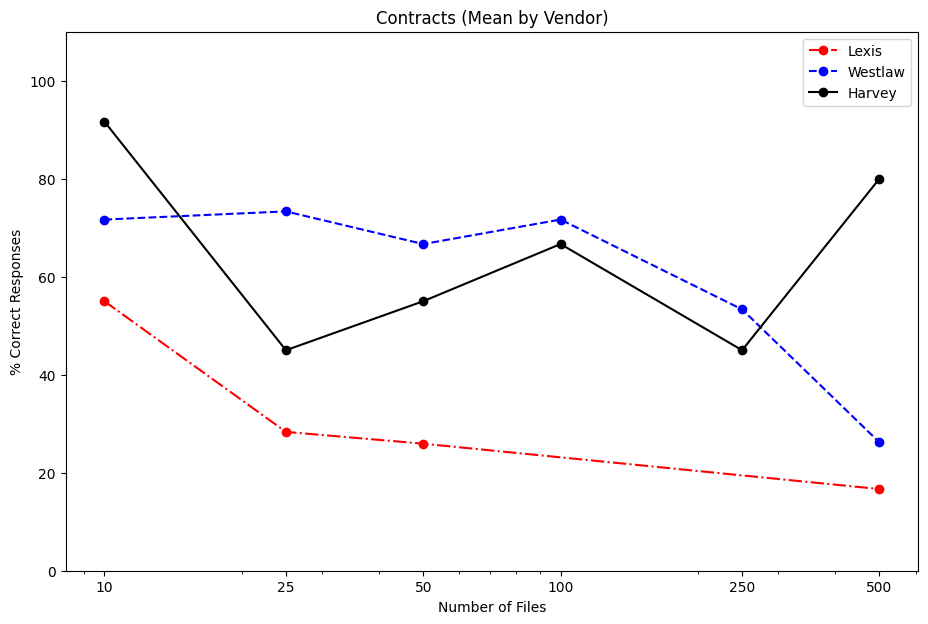

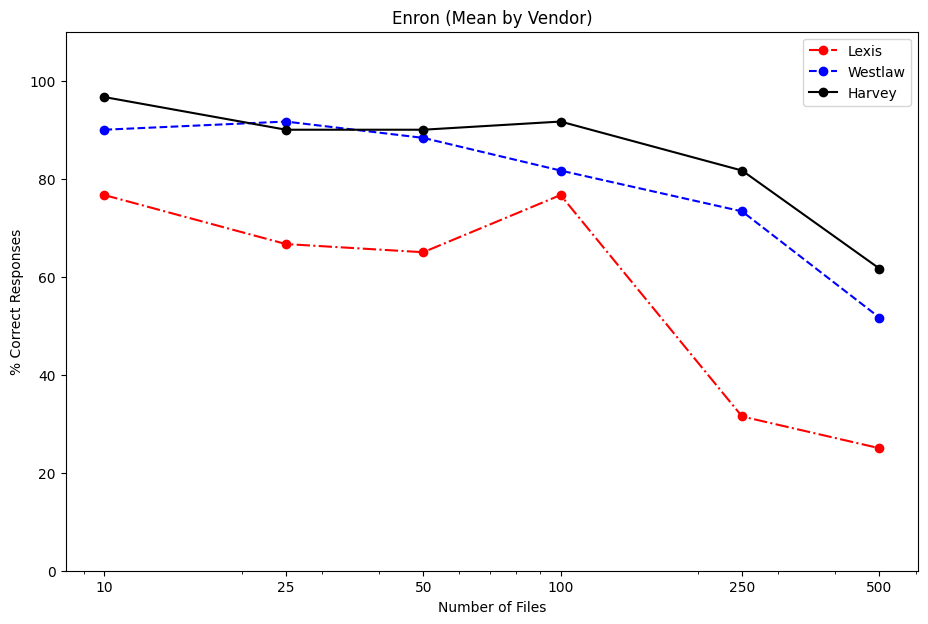

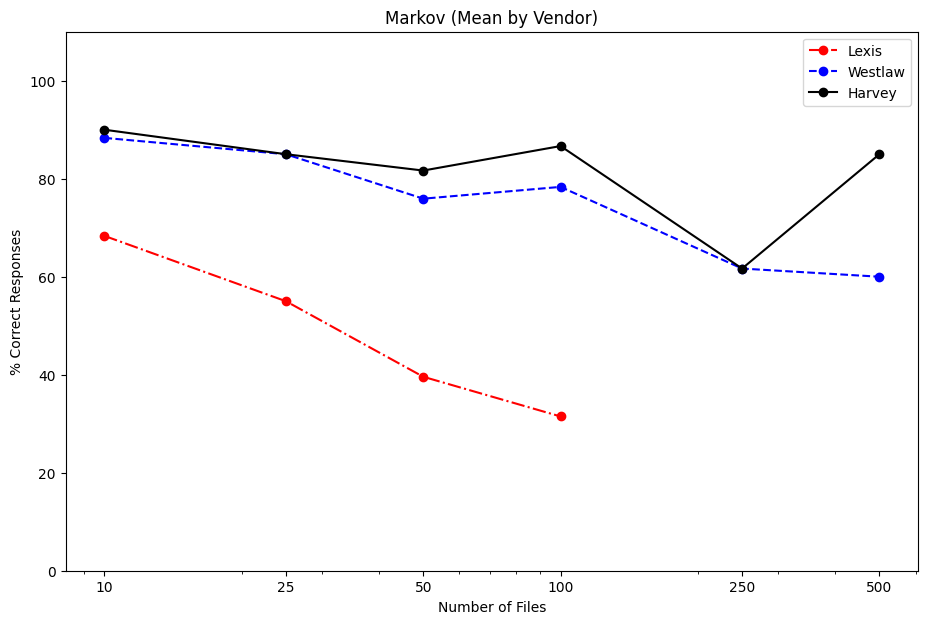

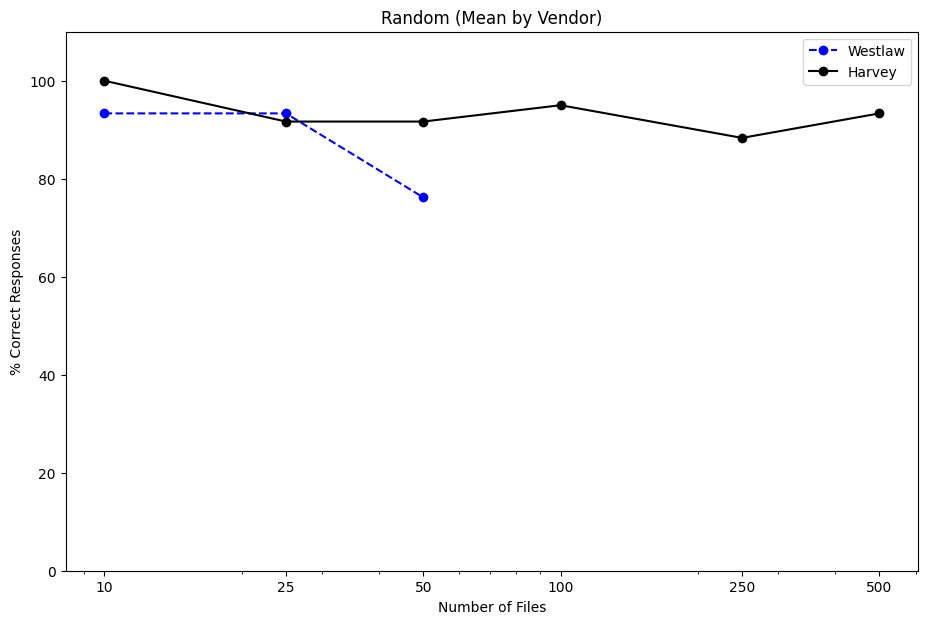

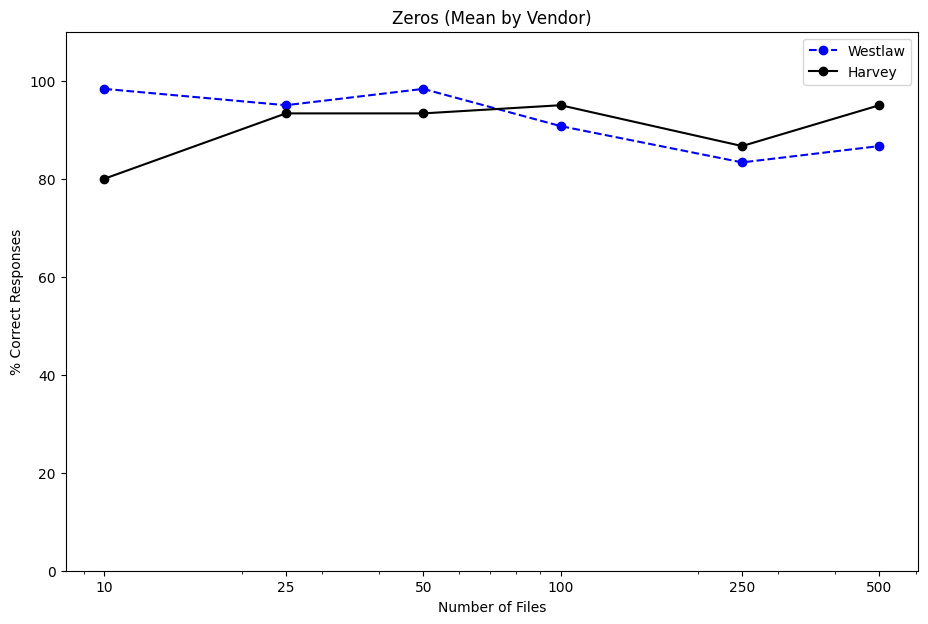

In [55]:
import matplotlib.pyplot as plt
from itertools import cycle

VENDOR_COLORS = {
    'Harvey': 'k',
    'Westlaw': 'b',
    'Lexis': 'r',
}

VENDOR_STYLES = {
    'Harvey': '-',
    'Westlaw': '--',
    'Lexis': '-.',
}

def compare_vendors_by_corpus(
    corpora=('contracts', 'enron', 'markov', 'random', 'zeros'),
    center_key='mean',
    y_max=110,
    figsize=(11, 7),
):
    fallback_styles = cycle(['-', '--', '-.', ':', (0, (1, 1)), (0, (3, 1, 1, 1))])

    for corp in corpora:
        plt.figure(figsize=figsize)

        all_xs = sorted({
            x
            for _, vdict in stats_dict.items()
            if corp in vdict
            for x in vdict[corp].keys()
        })

        for vendor, vdict in stats_dict.items():
            if corp not in vdict:
                continue

            d = vdict[corp]
            xs = sorted(d.keys())
            ys = [d[x][center_key] for x in xs]

            color = VENDOR_COLORS.get(vendor, None)
            linestyle = VENDOR_STYLES.get(vendor, next(fallback_styles))

            plt.plot(xs, ys, marker='o', label=vendor, color=color, linestyle=linestyle)

        plt.xscale('log')
        if all_xs:
            plt.xticks(all_xs, [str(x) for x in all_xs])

        plt.ylim(0, y_max)
        plt.xlabel('Number of Files')
        plt.ylabel('% Correct Responses')
        plt.title(f'{corp.title()} ({center_key.title()} by Vendor)')
        plt.legend()
        plt.savefig(f'../data_visualizations/corpora_compared/{corp}.png')
        plt.show()

compare_vendors_by_corpus()

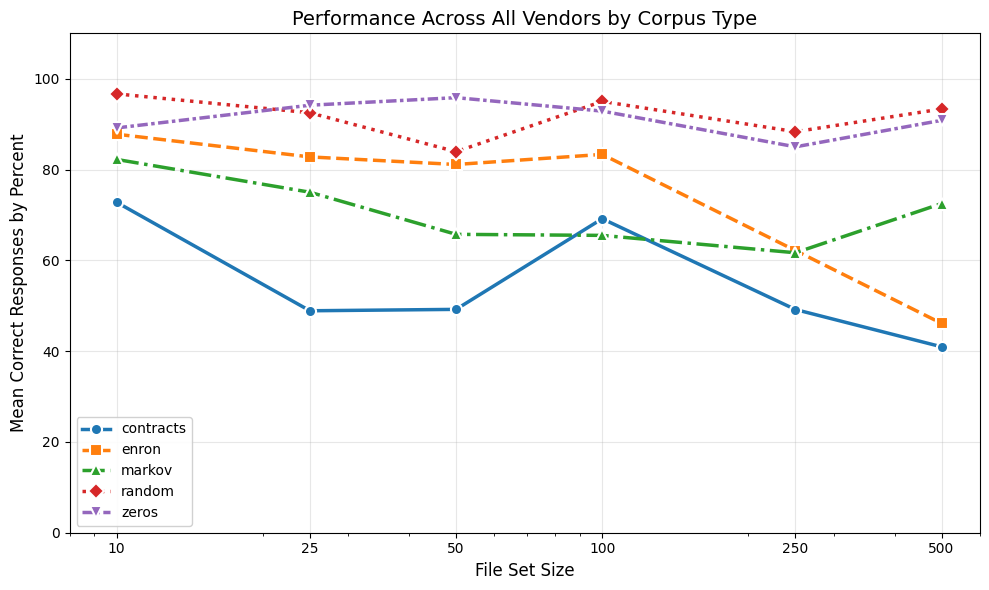

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

corpora_data = corp_avg_dict
plt.figure(figsize=(10, 6))
line_styles = cycle(['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))])
markers = cycle(['o', 's', '^', 'D', 'v'])

for corpus, data in corpora_data.items():
    xs = sorted(data.keys())
    ys = [data[x] for x in xs]
    plt.plot(xs, ys, 
             linestyle=next(line_styles), 
             marker=next(markers), 
             label=corpus, 
             linewidth=2.5, 
             markersize=8,
             markeredgewidth=1.5,
             markeredgecolor='white')

plt.xscale('log')
plt.xticks([10, 25, 50, 100, 250, 500], ['10', '25', '50', '100', '250', '500'])
plt.xlabel('File Set Size', fontsize=12)
plt.ylabel('Mean Correct Responses by Percent', fontsize=12)
plt.title('Performance Across All Vendors by Corpus Type', fontsize=14)
plt.ylim(0, 110)
plt.xlim(8, 600)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data_visualizations/corpora_compared/corpus_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
corpora_data

{}

In [26]:
corp_avg_dict_no_lx = {}
for corp in ['contracts', 'enron', 'markov', 'random', 'zeros']:
    small_avgs = defaultdict(list)
    for vender in paired_points:
        if corp in paired_points[vender].keys() and (vender != 'Lexis'):
            for size, val in paired_points[vender][corp]:
                if not all([vender == 'Westlaw', size > 500, corp == 'random']) or all():
                    # print(corp, vender, size, val)
                    small_avgs[size].append(val)
    small_avgs = {k: sum(v)/len(v) for k, v in small_avgs.items()}
    corp_avg_dict_no_lx[corp] = small_avgs
pprint(corp_avg_dict_no_lx)

{'contracts': {10: 81.66666666666666,
               25: 59.16666666666667,
               50: 60.83333333333333,
               100: 69.16666666666666,
               250: 49.16666666666667,
               500: 53.095238095238095},
 'enron': {10: 93.33333333333333,
           25: 90.83333333333333,
           50: 89.16666666666666,
           100: 86.66666666666666,
           250: 77.5,
           500: 56.66666666666667},
 'markov': {10: 89.16666666666666,
            25: 85.0,
            50: 78.79629629629629,
            100: 82.5,
            250: 61.666666666666664,
            500: 72.5},
 'random': {10: 96.66666666666667,
            25: 92.5,
            50: 83.92857142857142,
            100: 95.0,
            250: 88.33333333333334,
            500: 93.33333333333334},
 'zeros': {10: 89.16666666666667,
           25: 94.16666666666667,
           50: 95.83333333333334,
           100: 92.87037037037037,
           250: 85.0,
           500: 90.83333333333333}}


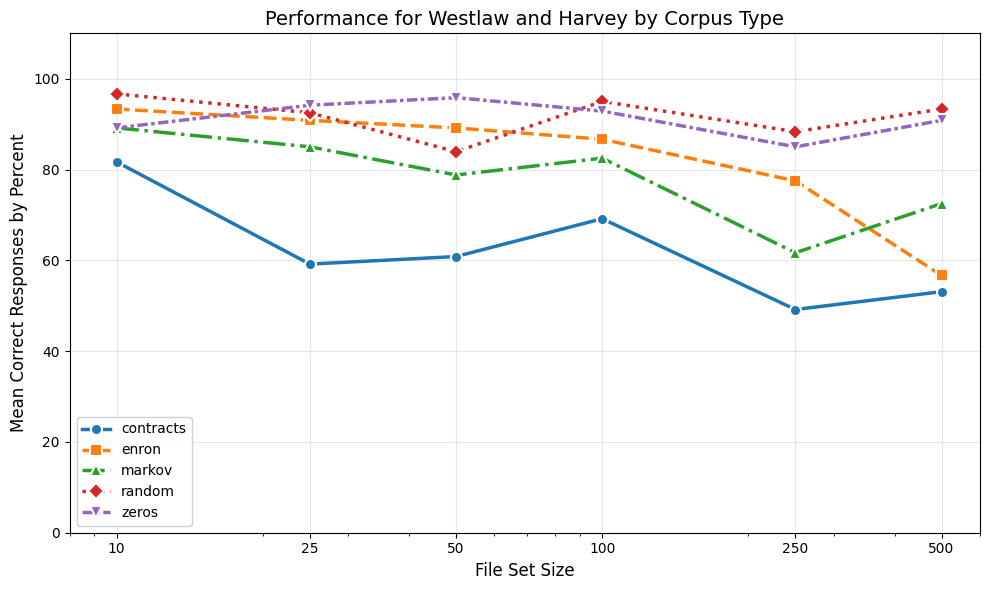

In [60]:
corpora_data = corp_avg_dict_no_lx
plt.figure(figsize=(10, 6))
line_styles = cycle(['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))])
markers = cycle(['o', 's', '^', 'D', 'v'])

for corpus, data in corpora_data.items():
    xs = sorted(data.keys())
    ys = [data[x] for x in xs]
    plt.plot(xs, ys, 
             linestyle=next(line_styles), 
             marker=next(markers), 
             label=corpus, 
             linewidth=2.5, 
             markersize=8,
             markeredgewidth=1.5,
             markeredgecolor='white')

plt.xscale('log')
plt.xticks([10, 25, 50, 100, 250, 500], ['10', '25', '50', '100', '250', '500'])
plt.xlabel('File Set Size', fontsize=12)
plt.ylabel('Mean Correct Responses by Percent', fontsize=12)
plt.title('Performance for Westlaw and Harvey by Corpus Type', fontsize=14)
plt.ylim(0, 110)
plt.xlim(8, 600)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data_visualizations/corpora_compared/corpus_comparison_no_lex.png', dpi=300, bbox_inches='tight')
plt.show()

----------------------

# ANOVA

In [29]:
from itertools import combinations
import math
from scipy.stats import studentized_range, f

In [30]:
pprint(new_dict)

{'Harvey': {'contracts': {10: [100.0,
                               100.0,
                               100.0,
                               83.33333333333333,
                               83.33333333333333,
                               66.66666666666667,
                               100.0,
                               100.0,
                               100.0,
                               83.33333333333333],
                          25: [50.0,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0,
                               33.333333333333336,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0],
                          50: [50.0,
                               50.0,
                               50.0,
                               33.3333333333333

In [31]:
anova_count = {i: [] for i in ['contracts', 'enron', 'markov', 'random', 'zeros']}
for vendor in new_dict:
    for corpus in new_dict[vendor]:
        for size in new_dict[vendor][corpus]:
            anova_count[corpus] += [j for j in new_dict[vendor][corpus][size] if j]
pprint(anova_count)
for corp in anova_count:
    print(corp, len(anova_count[corp]))
    

{'contracts': [50.0,
               66.66666666666667,
               66.66666666666667,
               83.33333333333333,
               50.0,
               66.66666666666667,
               50.0,
               33.333333333333336,
               50.0,
               33.333333333333336,
               33.333333333333336,
               33.333333333333336,
               16.666666666666668,
               33.333333333333336,
               33.333333333333336,
               33.333333333333336,
               16.666666666666668,
               16.666666666666668,
               33.333333333333336,
               33.333333333333336,
               33.333333333333336,
               16.666666666666668,
               33.333333333333336,
               33.333333333333336,
               33.333333333333336,
               16.666666666666668,
               16.666666666666668,
               33.333333333333336,
               16.666666666666668,
               16.666666666666668,
          

In [32]:
def mean(d_list):
    return sum(d_list)/len(d_list)

In [33]:
def anova(data: dict):
    all_vals = [x for xs in data.values() for x in xs]
    N = len(all_vals)
    k = len(data)

    grand_mean = mean(all_vals)

    group_means = {g: mean(xs) for g, xs in data.items()}
    ns = {g: len(xs) for g, xs in data.items()}

    ssb = sum(ns[g] * (group_means[g] - grand_mean) ** 2 for g in data)

    ssw = 0.0
    for g, xs in data.items():
        m = group_means[g]
        for x in xs:
            ssw += (x - m) ** 2

    msb = ssb / (k - 1)
    msw = ssw / (N - k)

    return msw, msb, msb / msw, N, k



In [34]:
msw, msb, F_obs, N, k = anova(anova_count)
print(f'MSW: {msw}, MSB: {msb}, F: {F_obs}')

df1 = k - 1 ; df2 = N - k
p_value = f.sf(F_obs, df1, df2)
print(f'P-Value: {p_value}')

MSW: 504.98417011012174, MSB: 32365.930251294423, F: 64.09296007087984
P-Value: 3.264267270254008e-46


In [35]:
def Tukey(data, msw, alpha=0.05):
    N = sum(len(xs) for xs in data.values())
    k = len(data)
    df_e = N - k

    qcrit = studentized_range.ppf(1 - alpha, k, df_e)

    for a, b in combinations(data.keys(), 2):
        na = len(data[a])
        nb = len(data[b])

        dij = abs(mean(data[a]) - mean(data[b]))

        se = (msw / 2.0 * (1.0 / na + 1.0 / nb)) ** 0.5

        hsd_ab = qcrit * se

        print((a, b), "dij=", dij, "HSD=", hsd_ab, "reject?", dij > hsd_ab)


In [36]:
Tukey(anova_count, msw)

('contracts', 'enron') dij= 19.844622905027926 HSD= 6.68634843354653 reject? True
('contracts', 'markov') dij= 15.054320040899789 HSD= 6.839480722434251 reject? True
('contracts', 'random') dij= 37.683189655172406 HSD= 8.186617908234421 reject? True
('contracts', 'zeros') dij= 37.04569327731091 HSD= 7.439509313078026 reject? True
('enron', 'markov') dij= 4.790302864128137 HSD= 6.653779390287272 reject? False
('enron', 'random') dij= 17.83856675014448 HSD= 8.0321227827696 reject? True
('enron', 'zeros') dij= 17.201070372282985 HSD= 7.269152800803997 reject? True
('markov', 'random') dij= 22.628869614272617 HSD= 8.160039067017147 reject? True
('markov', 'zeros') dij= 21.99137323641112 HSD= 7.410251252096396 reject? True
('random', 'zeros') dij= 0.6374963778614955 HSD= 8.669142970448174 reject? False


-----------
# exponential regression to ALL point

In [37]:
pprint(new_dict)

{'Harvey': {'contracts': {10: [100.0,
                               100.0,
                               100.0,
                               83.33333333333333,
                               83.33333333333333,
                               66.66666666666667,
                               100.0,
                               100.0,
                               100.0,
                               83.33333333333333],
                          25: [50.0,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0,
                               33.333333333333336,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0],
                          50: [50.0,
                               50.0,
                               50.0,
                               33.3333333333333

### trying averaging and weighting values

In [38]:
def mean(l: list):
    l = [j for j in l if j is not None]
    return sum(l)/len(l)

weighted_dict = copy.deepcopy(new_dict)
for vendor in new_dict:
    for corp in new_dict[vendor]:
        for size in new_dict[vendor][corp]:
            if len([i for i in new_dict[vendor][corp][size] if i is not None]) >= len(new_dict[vendor][corp][size])/2:
                weighted_dict[vendor][corp][size] = {'mean': mean(new_dict[vendor][corp][size]), 'weight': len(new_dict[vendor][corp][size])}
            else:
                weighted_dict[vendor][corp][size] = {'mean': None, 'weight': None}
                
pprint(weighted_dict)

{'Harvey': {'contracts': {10: {'mean': 91.66666666666666, 'weight': 10},
                          25: {'mean': 45.0, 'weight': 10},
                          50: {'mean': 55.0, 'weight': 10},
                          100: {'mean': 66.66666666666666, 'weight': 10},
                          250: {'mean': 45.0, 'weight': 10},
                          500: {'mean': 80.0, 'weight': 10}},
            'enron': {10: {'mean': 96.66666666666666, 'weight': 10},
                      25: {'mean': 90.0, 'weight': 10},
                      50: {'mean': 90.0, 'weight': 10},
                      100: {'mean': 91.66666666666666, 'weight': 10},
                      250: {'mean': 81.66666666666666, 'weight': 10},
                      500: {'mean': 61.66666666666667, 'weight': 10}},
            'markov': {10: {'mean': 90.0, 'weight': 10},
                       25: {'mean': 85.0, 'weight': 10},
                       50: {'mean': 81.66666666666666, 'weight': 10},
                       100: {'mean

In [39]:
def make_arrays(dict_of_vendor: dict):
    final_x, final_y, weights = [], [], []
    for corp in dict_of_vendor:
        for size in dict_of_vendor[corp]:
            if dict_of_vendor[corp][size]['mean'] is not None:
                final_x.append(size)
                final_y.append(dict_of_vendor[corp][size]['mean'])
                weights.append(dict_of_vendor[corp][size]['weight'])
    return (
        np.array(final_x, dtype=float),
        np.array(final_y, dtype=float),
        np.array(weights, dtype=float),
    )

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

def fit_model_all_data(dict_of_vendor: dict, absolute_sigma=False):
    x, y, weights = make_arrays(dict_of_vendor)

    if len(y) < 3:
        raise ValueError("Need at least 3 points to fit a, b, c.")
    if np.any(weights <= 0) or np.any(~np.isfinite(weights)):
        raise ValueError("All weights must be positive and finite.")

    sigma = 1.0 / np.sqrt(weights)

    c0 = float(np.min(y))
    a0 = float(np.max(y) - np.min(y))
    b0 = 0.01

    popt, pcov = curve_fit(
        exp_decay, x, y,
        p0=[a0, b0, c0],
        sigma=sigma,
        absolute_sigma=absolute_sigma,
        maxfev=10000
    )
    se = np.sqrt(np.diag(pcov))

    yhat = exp_decay(x, *popt)

    ybar_w = np.sum(weights * y) / np.sum(weights)
    ss_res_w = np.sum(weights * (y - yhat) ** 2)
    ss_tot_w = np.sum(weights * (y - ybar_w) ** 2)
    r2_w = 1.0 - ss_res_w / ss_tot_w if ss_tot_w > 0 else float("nan")

    mae_w = np.sum(weights * np.abs(y - yhat)) / np.sum(weights)

    ahat, bhat, chat = popt
    return ahat, bhat, chat, se, r2_w, mae_w


weighted_fit = {}
for vendor in weighted_dict:
    ahat, bhat, chat, se, r2_w, mae_w = fit_model_all_data(weighted_dict[vendor])
    weighted_fit[vendor] = {
        'a': ahat,
        'b': bhat,
        'c': chat,
        'R2': r2_w,
        'MAE': mae_w,
        'se(a)': se[0],
        'se(b)': se[1],
        'se(c)': se[2],
    }

pprint(weighted_fit)


{'Harvey': {'MAE': np.float64(11.012908103723616),
            'R2': np.float64(0.051548976128866775),
            'a': np.float64(10.621015865108445),
            'b': np.float64(0.017072779441272903),
            'c': np.float64(79.19689579320652),
            'se(a)': np.float64(9.663385613679283),
            'se(b)': np.float64(0.03696052245590173),
            'se(c)': np.float64(5.128298516116099)},
 'Lexis': {'MAE': np.float64(12.548648727374964),
           'R2': np.float64(0.38972271866364583),
           'a': np.float64(43.73806228665042),
           'b': np.float64(0.004391553081846015),
           'c': np.float64(16.614480762336385),
           'se(a)': np.float64(25.64156998524692),
           'se(b)': np.float64(0.0074826720702863),
           'se(c)': np.float64(29.19194448894827)},
 'Westlaw': {'MAE': np.float64(9.41220696372618),
             'R2': np.float64(0.4579156113458568),
             'a': np.float64(47.41448608783129),
             'b': np.float64(0.002374426

In [40]:
with open('fit_stats.json', 'w') as outfile:
    json.dump({'stats_dict': stats_dict, 'weighted_fit': weighted_fit}, outfile, indent=4)

In [61]:
def make_vendor_median_lines(vendor, fit_dict=None, stats_dict=None, out_dir="data_visualizations/vendor_means"):
    if stats_dict is None:
        raise ValueError("No Stats Dict")

    vendor_dict = stats_dict[vendor]

    style_cycle = cycle(['-', '--', '-.', ':', (0, (1, 1)), (0, (3, 1, 1, 1))])
    plt.figure(figsize=(10, 6))

    all_xs = set()
    ylab = "Mean Correct Responses"

    for corp, d in vendor_dict.items():
        xs = sorted(d.keys())
        all_xs.update(xs)

        if xs and isinstance(d[xs[0]], dict) and ('mean' in d[xs[0]]):
            ys = [d[x]['mean'] for x in xs]
            ylab = "Mean Correct Responses by Percent"
        else:
            ys = [(d[x]['q1'] + d[x]['q3']) / 2 for x in xs]
            ylab = "(q1+q3)/2"

        plt.plot(xs, ys, linestyle=next(style_cycle), marker='o', label=corp, alpha=0.7)

    if fit_dict is not None and vendor in fit_dict:
        fr = fit_dict[vendor]
        a = float(fr["a"])
        b = float(fr["b"])
        c = float(fr["c"])
        r2 = float(fr["R2"])
        print(r2)

        all_xs_sorted = sorted(all_xs)
        x_smooth = np.linspace(min(all_xs_sorted), max(all_xs_sorted), 300)
        y_smooth = a * np.exp(-b * x_smooth) + c

        label = f"Exponential Decay (R²={r2:.3f})"

        plt.plot(x_smooth, y_smooth, 'k--', linewidth=2.5, alpha=0.85, label=label)

    all_xs_sorted = sorted(all_xs)
    plt.xscale('log')
    plt.xticks(all_xs_sorted, [str(x) for x in all_xs_sorted])
    plt.xlabel('Number of Files')
    plt.ylabel(ylab)
    plt.ylim(0, 110)
    plt.xlim(min(all_xs_sorted) * 0.8, max(all_xs_sorted) * 1.2)
    plt.title(f'{vendor} Fitted to Exponential Decay')
    plt.legend()
    plt.grid(True, alpha=0.3)

    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f'{out_dir}/{vendor}_mean_by_corp.png', dpi=300, bbox_inches="tight")
    plt.show()


0.38972271866364583


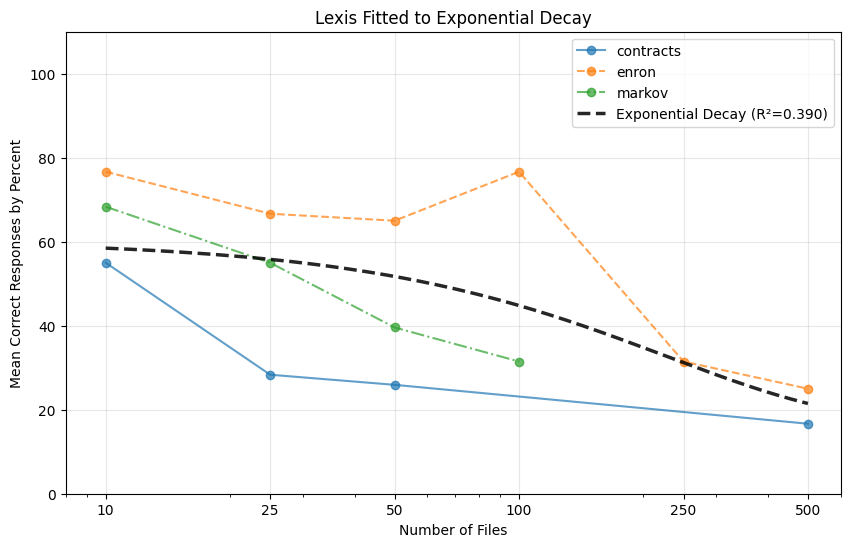

0.4579156113458568


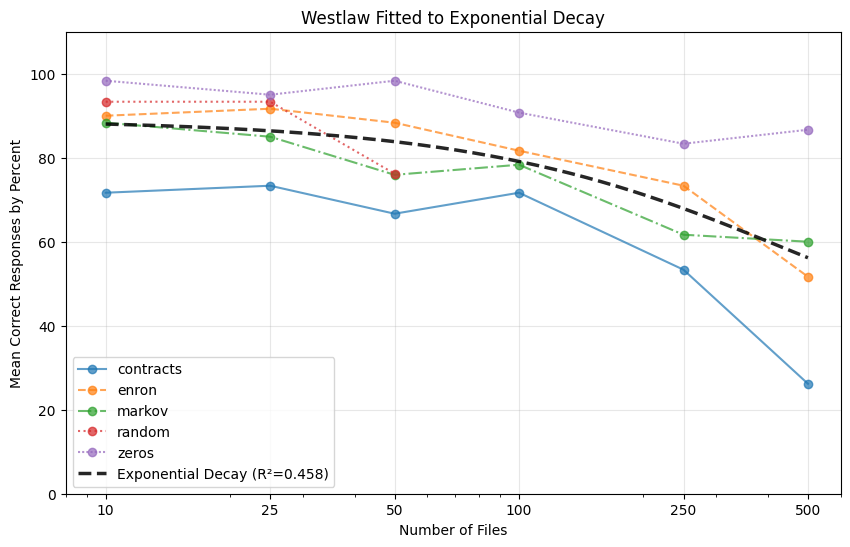

0.051548976128866775


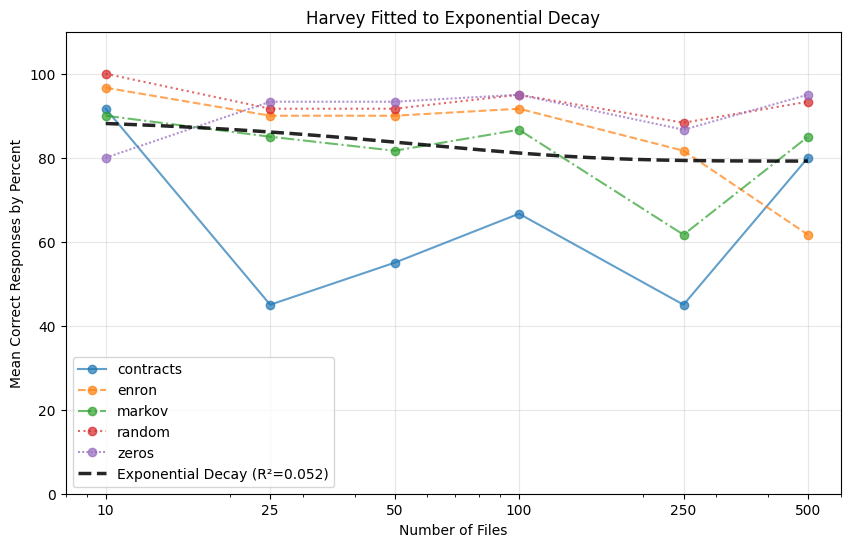

In [62]:
for vendor in weighted_fit:
    make_vendor_median_lines(vendor, fit_dict=weighted_fit, stats_dict=stats_dict, out_dir="../data_visualizations/vendor_means")

In [47]:
pprint(new_dict)
for vend in new_dict:
    count = 0
    for corp in new_dict[vend]:
        for size in new_dict[vend][corp]:
            count += len([i for i in new_dict[vend][corp][size] if i is not None])
    print(vend, count)

{'Harvey': {'contracts': {10: [100.0,
                               100.0,
                               100.0,
                               83.33333333333333,
                               83.33333333333333,
                               66.66666666666667,
                               100.0,
                               100.0,
                               100.0,
                               83.33333333333333],
                          25: [50.0,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0,
                               33.333333333333336,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0],
                          50: [50.0,
                               50.0,
                               50.0,
                               33.3333333333333

In [48]:
pprint(new_dict)
for vend in new_dict:
    avgs = defaultdict(list)
    for corp in new_dict[vend]:
        for size in [10, 500]:
            avgs[size] += [i for i in new_dict[vend][corp][size] if i is not None]
    for k in avgs:
        avgs[k] = mean(avgs[k])
    # print(vend, avgs)

{'Harvey': {'contracts': {10: [100.0,
                               100.0,
                               100.0,
                               83.33333333333333,
                               83.33333333333333,
                               66.66666666666667,
                               100.0,
                               100.0,
                               100.0,
                               83.33333333333333],
                          25: [50.0,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0,
                               33.333333333333336,
                               33.333333333333336,
                               50.0,
                               50.0,
                               50.0],
                          50: [50.0,
                               50.0,
                               50.0,
                               33.3333333333333